# Esteira de ML com MLflow — Yggdrasil

Notebook orquestrador da esteira. Recebe (ou treina) um modelo e gera, de ponta a ponta:
métricas por amostra (DES/OOT), grupos homogêneos (**ratings**), **shifts** DES→OOT,
**PSI** ao longo do tempo, **SHAP** e relatórios por grupo — tudo logado no **MLflow**.

> A primeira célula de código é de **parâmetros** (compatível com papermill).
> No Databricks, troque a célula de carga por `spark.read.table(input_path).toPandas()`.

In [ ]:
# --- Bootstrap: torna o pacote `yggdrasil` importável a partir do repositório,
# sem `pip install`. Sobe do diretório atual até a raiz do repo (onde fica a
# pasta `yggdrasil/`) e a coloca no sys.path. Funciona no clone local (Jupyter/
# VS Code) e no Databricks Repos; se o pacote já estiver instalado, é inofensivo.
import sys
from pathlib import Path

for _base in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
    if (_base / "yggdrasil" / "__init__.py").is_file():
        if str(_base) not in sys.path:
            sys.path.insert(0, str(_base))
        break


In [1]:
# Parâmetros (papermill: célula com a tag 'parameters')
input_path = ""                      # CSV/Parquet; vazio => dataset sintético de exemplo
col_date = "dt_ref"
col_amostra = "amostra"
col_target = "target"
feature_prefix = "feat_"
problem_type = "classification"      # "classification" | "regression"
ratings = ["decis", "quantil", "arvore", "optbin"]
analysis_samples = ("DES", "OOT")    # demais amostras (SIMUL/BACKTEST) => só score + rating
mlflow_tracking_uri = "file:./mlruns"
experiment_path = "esteira_demo"     # no Databricks: "/Shared/Yggdrasil/<modelo>"
run_name = "esteira-demo" 

In [2]:
import os
import numpy as np
import pandas as pd
import mlflow
from yggdrasil import MLPipeline, ColumnConfig

os.environ.setdefault("MLFLOW_ALLOW_FILE_STORE", "true")  # habilita o backend ./mlruns local
mlflow.set_tracking_uri(mlflow_tracking_uri)

## 1. Carga de dados

In [3]:
# Databricks:  df = spark.read.table(input_path).toPandas()
if input_path:
    df = pd.read_parquet(input_path) if input_path.endswith(".parquet") else pd.read_csv(input_path)
    df[col_date] = pd.to_datetime(df[col_date])
else:
    # Dataset sintético só para rodar o notebook de ponta a ponta.
    rng = np.random.default_rng(42)
    n = 6000
    meses = pd.date_range("2023-01-01", periods=12, freq="MS")
    if problem_type == "classification":
        from sklearn.datasets import make_classification
        X, y = make_classification(n_samples=n, n_features=8, n_informative=5,
                                   weights=[0.85], random_state=42)
    else:
        from sklearn.datasets import make_regression
        X, y = make_regression(n_samples=n, n_features=8, n_informative=5,
                               noise=12.0, random_state=42)
        y = (y - y.min()) / (y.max() - y.min())   # escala 0..1 (estilo LGD)
    df = pd.DataFrame(X, columns=[f"{feature_prefix}{i:02d}" for i in range(8)])
    df[col_target] = y
    df[col_date] = rng.choice(meses, size=n)
    df[col_amostra] = np.where(df[col_date] >= meses[8], "OOT", "DES")
    df.loc[df.sample(frac=0.05, random_state=1).index, col_amostra] = "SIMUL"

df.head()

,feat_00,feat_01,feat_02,feat_03,feat_04,feat_05,feat_06,feat_07,target,dt_ref,amostra
0,1.480165,-0.012221,-0.339884,-0.196828,1.286657,-0.033762,1.915359,0.401581,0,2023-02-01,DES
1,2.239870,-1.482303,-1.360985,-2.670768,1.970196,-0.595838,0.522434,0.749771,0,2023-10-01,OOT
2,-0.550378,-0.431668,-0.323266,-1.298574,1.562445,-3.400527,-0.702898,-3.331440,0,2023-08-01,DES
3,0.173684,-0.930891,-1.481608,-0.955955,1.548368,-1.615092,-0.554883,-1.141329,0,2023-06-01,DES
4,0.272473,-1.246600,1.552483,-0.202728,3.202185,-2.329459,-0.847979,-1.985514,0,2023-06-01,SIMUL


## 2. Configuração e modelo
Treine o seu modelo ou use o baseline abaixo. O treino com PyCaret é opcional (célula seguinte).

In [4]:
cfg = ColumnConfig(
    feature_prefix=feature_prefix, date_col=col_date, sample_col=col_amostra,
    target_col=col_target, analysis_samples=tuple(analysis_samples),
)

feature_cols = cfg.feature_columns(df)
dev = df[df[col_amostra] == cfg.dev_sample]

if problem_type == "classification":
    from sklearn.ensemble import RandomForestClassifier
    model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
else:
    from sklearn.ensemble import RandomForestRegressor
    model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(dev[feature_cols], dev[col_target])

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
# (Opcional) Treino automatizado com PyCaret — pip install -e ".[pycaret]"
# from yggdrasil.training.pycaret_adapter import PyCaretTrainer
# trainer = PyCaretTrainer(problem_type=problem_type)
# resultado = pipe.run(df, trainer=trainer, experiment=experiment_path, run_name=run_name)

## 3. Executa a esteira (loga tudo no MLflow)

In [6]:
pipe = MLPipeline(cfg, problem_type=problem_type, ratings=ratings)
resultado = pipe.run(df, model=model, experiment=experiment_path, run_name=run_name)
print("run_id:", resultado.run_id)
print("ratings:", resultado.rating_cols)

2026/06/14 22:51:36 INFO mlflow.tracking.fluent: Experiment with name 'esteira_demo' does not exist. Creating a new experiment.


2026/06/14 22:52:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/06/14 22:52:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


run_id: e5845dcb7be34b2d99fd1a4805d4964b
ratings: ['rating_decis', 'rating_quantil', 'rating_arvore', 'rating_optbin']


## 4. Métricas, shifts e PSI

In [7]:
print("Métricas por amostra (DES/OOT):")
display(pd.DataFrame(resultado.metrics_by_sample).T)
print("Shifts DES -> OOT:")
display(pd.Series(resultado.shifts, name="shift").to_frame())
print("PSI agregado (DES -> OOT):")
display(pd.Series(resultado.psi_metrics, name="psi").to_frame())

Métricas por amostra (DES/OOT):


,auc,gini,ks,ks_cutoff,accuracy,f1,precision,recall,brier,logloss
DES,1.000000,1.000000,1.000000,0.54,1.00000,1.000000,1.000000,1.000000,0.006033,0.041112
OOT,0.957666,0.915333,0.824691,0.54,0.94462,0.803738,0.926724,0.709571,0.043182,0.209250


Shifts DES -> OOT:


,shift
auc_shift_abs,-0.042334
auc_shift_rel,-0.042334
gini_shift_abs,-0.084667
gini_shift_rel,-0.084667
ks_shift_abs,-0.175309
ks_shift_rel,-0.175309
accuracy_shift_abs,-0.055380
accuracy_shift_rel,-0.055380
f1_shift_abs,-0.196262
f1_shift_rel,-0.196262


PSI agregado (DES -> OOT):


,psi
psi_score_oot,0.249016
psi_rating_decis_oot,0.249016
psi_rating_quantil_oot,0.240746
psi_rating_arvore_oot,0.002618
psi_rating_optbin_oot,0.000000


## 5. Relatório por grupo homogêneo

In [8]:
for col, rep in resultado.reports.items():
    print(f"=== {col} ===")
    display(rep)

=== rating_decis ===


,rating,volume,pct_volume,score_medio,target_medio,score_min,score_max,vol_DES,pct_DES,target_medio_DES,score_medio_DES,vol_OOT,pct_OOT,target_medio_OOT,score_medio_OOT
0,R01,1431,25.105263,0.000000,0.002096,0.000,0.000,1128,29.652997,0.000000,0.000000,303,15.981013,0.009901,0.000000
1,R02,769,13.491228,0.005000,0.002601,0.005,0.005,556,14.616193,0.000000,0.005000,213,11.234177,0.009390,0.005000
2,R03,814,14.280702,0.012009,0.003686,0.010,0.015,544,14.300736,0.000000,0.011912,270,14.240506,0.011111,0.012204
3,R04,544,9.543860,0.024292,0.003676,0.020,0.030,360,9.463722,0.000000,0.024306,184,9.704641,0.010870,0.024266
4,R05,768,13.473684,0.054453,0.007812,0.035,0.085,453,11.908517,0.000000,0.053521,315,16.613924,0.019048,0.055794
5,R06,846,14.842105,0.366773,0.384161,0.090,0.820,379,9.963197,0.477573,0.422691,467,24.630802,0.308351,0.321392
6,R07,528,9.263158,0.938049,0.998106,0.825,1.000,384,10.094637,1.000000,0.942760,144,7.594937,0.993056,0.925486


=== rating_quantil ===


,rating,volume,pct_volume,score_medio,target_medio,score_min,score_max,vol_DES,pct_DES,target_medio_DES,score_medio_DES,vol_OOT,pct_OOT,target_medio_OOT,score_medio_OOT
0,A,2200,38.596491,0.001748,0.002273,0.000,0.005,1684,44.269190,0.000000,0.001651,516,27.215190,0.009690,0.002064
1,B,1358,23.824561,0.016929,0.003682,0.010,0.030,904,23.764458,0.000000,0.016847,454,23.945148,0.011013,0.017093
2,C,768,13.473684,0.054453,0.007812,0.035,0.085,453,11.908517,0.000000,0.053521,315,16.613924,0.019048,0.055794
3,D,455,7.982456,0.152033,0.052747,0.090,0.280,192,5.047319,0.000000,0.139219,263,13.871308,0.091255,0.161388
4,E,391,6.859649,0.616662,0.769821,0.285,0.820,187,4.915878,0.967914,0.713743,204,10.759494,0.588235,0.527672
5,F,528,9.263158,0.938049,0.998106,0.825,1.000,384,10.094637,1.000000,0.942760,144,7.594937,0.993056,0.925486


=== rating_arvore ===


,rating,volume,pct_volume,score_medio,target_medio,score_min,score_max,vol_DES,pct_DES,target_medio_DES,score_medio_DES,vol_OOT,pct_OOT,target_medio_OOT,score_medio_OOT
0,A,4887,85.736842,0.036233,0.016984,0.00,0.485,3239,85.147213,0.0,0.021917,1648,86.919831,0.050364,0.064369
1,B,813,14.263158,0.857522,0.965560,0.49,1.000,565,14.852787,1.0,0.873425,248,13.080169,0.887097,0.821290


=== rating_optbin ===


,rating,volume,pct_volume,score_medio,target_medio,score_min,score_max,vol_DES,pct_DES,target_medio_DES,score_medio_DES,vol_OOT,pct_OOT,target_medio_OOT,score_medio_OOT
0,A,5700,100.0,0.153375,0.152281,0.0,1.0,3804,100.0,0.148528,0.14839,1896,100.0,0.15981,0.163376


## 6. PSI dos ratings ao longo do tempo

In [9]:
from yggdrasil.monitoring import psi_rating_over_time
for col in resultado.rating_cols:
    print(f"--- {col} ---")
    display(psi_rating_over_time(resultado.df_scored, col, cfg))

--- rating_decis ---


,mes,psi,n,flag
0,2023-01-01,0.009782,463,estavel
1,2023-02-01,0.009592,546,estavel
2,2023-03-01,0.014455,508,estavel
3,2023-04-01,0.015372,505,estavel
4,2023-05-01,0.017604,489,estavel
5,2023-06-01,0.026893,509,estavel
6,2023-07-01,0.023860,523,estavel
7,2023-08-01,0.005357,470,estavel
8,2023-09-01,0.262628,478,instavel
9,2023-10-01,0.287881,506,instavel


--- rating_quantil ---


,mes,psi,n,flag
0,2023-01-01,0.021917,463,estavel
1,2023-02-01,0.006440,546,estavel
2,2023-03-01,0.012024,508,estavel
3,2023-04-01,0.005936,505,estavel
4,2023-05-01,0.006976,489,estavel
5,2023-06-01,0.021992,509,estavel
6,2023-07-01,0.023372,523,estavel
7,2023-08-01,0.003806,470,estavel
8,2023-09-01,0.270794,478,instavel
9,2023-10-01,0.277417,506,instavel


--- rating_arvore ---


,mes,psi,n,flag
0,2023-01-01,2.875272e-04,463,estavel
1,2023-02-01,8.980252e-04,546,estavel
2,2023-03-01,4.527013e-03,508,estavel
3,2023-04-01,1.262430e-04,505,estavel
4,2023-05-01,4.805576e-03,489,estavel
5,2023-06-01,3.649699e-03,509,estavel
6,2023-07-01,2.924011e-03,523,estavel
7,2023-08-01,1.182964e-04,470,estavel
8,2023-09-01,1.760994e-02,478,estavel
9,2023-10-01,1.451673e-04,506,estavel


--- rating_optbin ---


,mes,psi,n,flag
0,2023-01-01,0.0,463,estavel
1,2023-02-01,0.0,546,estavel
2,2023-03-01,0.0,508,estavel
3,2023-04-01,0.0,505,estavel
4,2023-05-01,0.0,489,estavel
5,2023-06-01,0.0,509,estavel
6,2023-07-01,0.0,523,estavel
7,2023-08-01,0.0,470,estavel
8,2023-09-01,0.0,478,estavel
9,2023-10-01,0.0,506,estavel


## 7. Dashboard

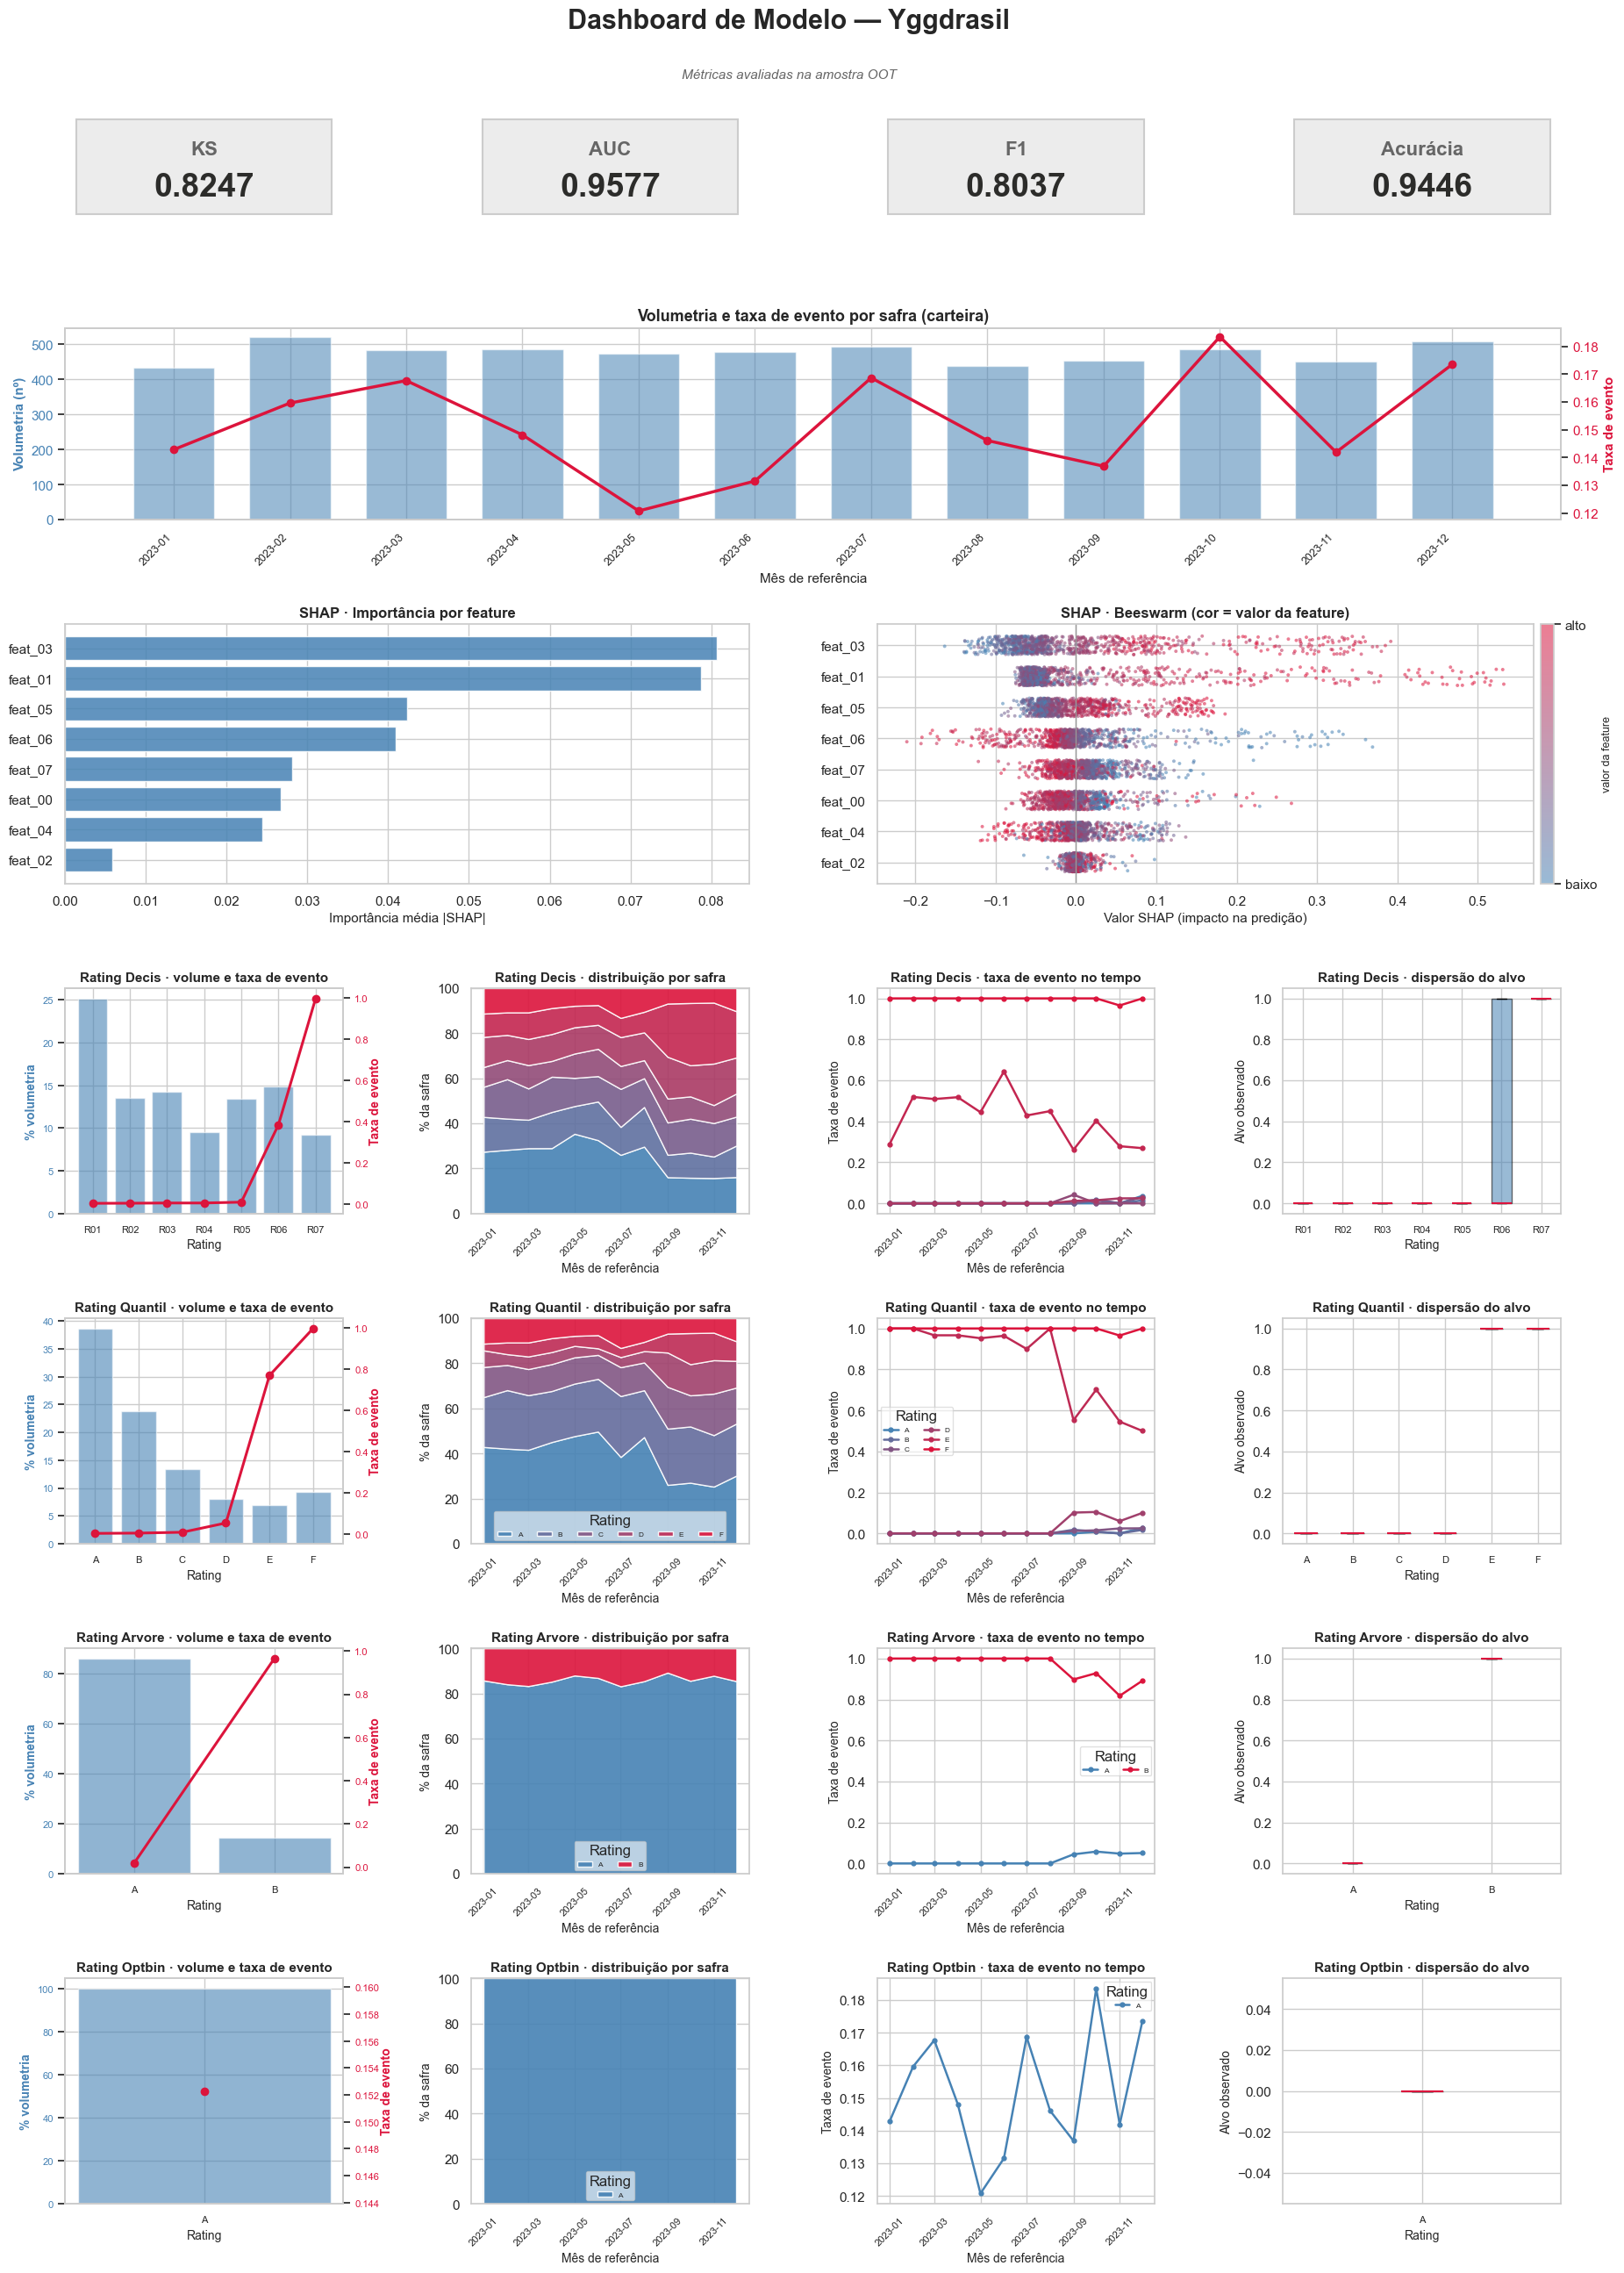

In [10]:
from yggdrasil.reporting import build_dashboard
df_an = resultado.df_scored[resultado.df_scored[col_amostra].isin(analysis_samples)]
# model + X_shap incluem a seção SHAP (importância + beeswarm) no painel.
fig = build_dashboard(df_an, resultado.rating_cols, cfg, problem_type,
                      metrics=resultado.metrics_by_sample.get(cfg.oot_sample, {}),
                      model=model, X_shap=dev[feature_cols])
fig